In [29]:
import os
import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow.keras import layers, models, initializers
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import visualkeras
from data_loader import load_processed_data as lpd

In [2]:
def create_baseline_densenet(input_shape=(224, 224, 3), num_classes=5):
    """
    Creates a simple DenseNet-based baseline model.
    
    Args:
        input_shape (tuple): Shape of the input images.
        num_classes (int): Number of output classes.
    
    Returns:
        tf.keras.Model: Baseline model.
    """
    inputs = tf.keras.Input(shape=input_shape)

    x = layers.Conv2D(16, (7, 7), strides=2, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding="same")(x)

    # Dense Block 1
    for _ in range(2):
        y = layers.BatchNormalization()(x)
        y = layers.ReLU()(y)
        y = layers.Conv2D(16, (3, 3), padding="same")(y)
        x = layers.Concatenate()([x, y])

    # Transition Layer
    x = layers.Conv2D(32, (1, 1), activation="relu")(x)
    x = layers.AveragePooling2D((2, 2))(x)

    # Dense Block 2
    for _ in range(2):  # Two layers in the block
        y = layers.BatchNormalization()(x)
        y = layers.ReLU()(y)
        y = layers.Conv2D(32, (3, 3), padding="same")(y)
        x = layers.Concatenate()([x, y])  # Dense connection

    # Transition to Output
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    # Create model
    model = models.Model(inputs, outputs)
    return model

In [3]:
baseline_model = create_baseline_densenet()
baseline_model.compile(optimizer="adam",
                       loss="sparse_categorical_crossentropy",
                       metrics=["accuracy"])

/opt/anaconda3/lib/python3.11/site-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


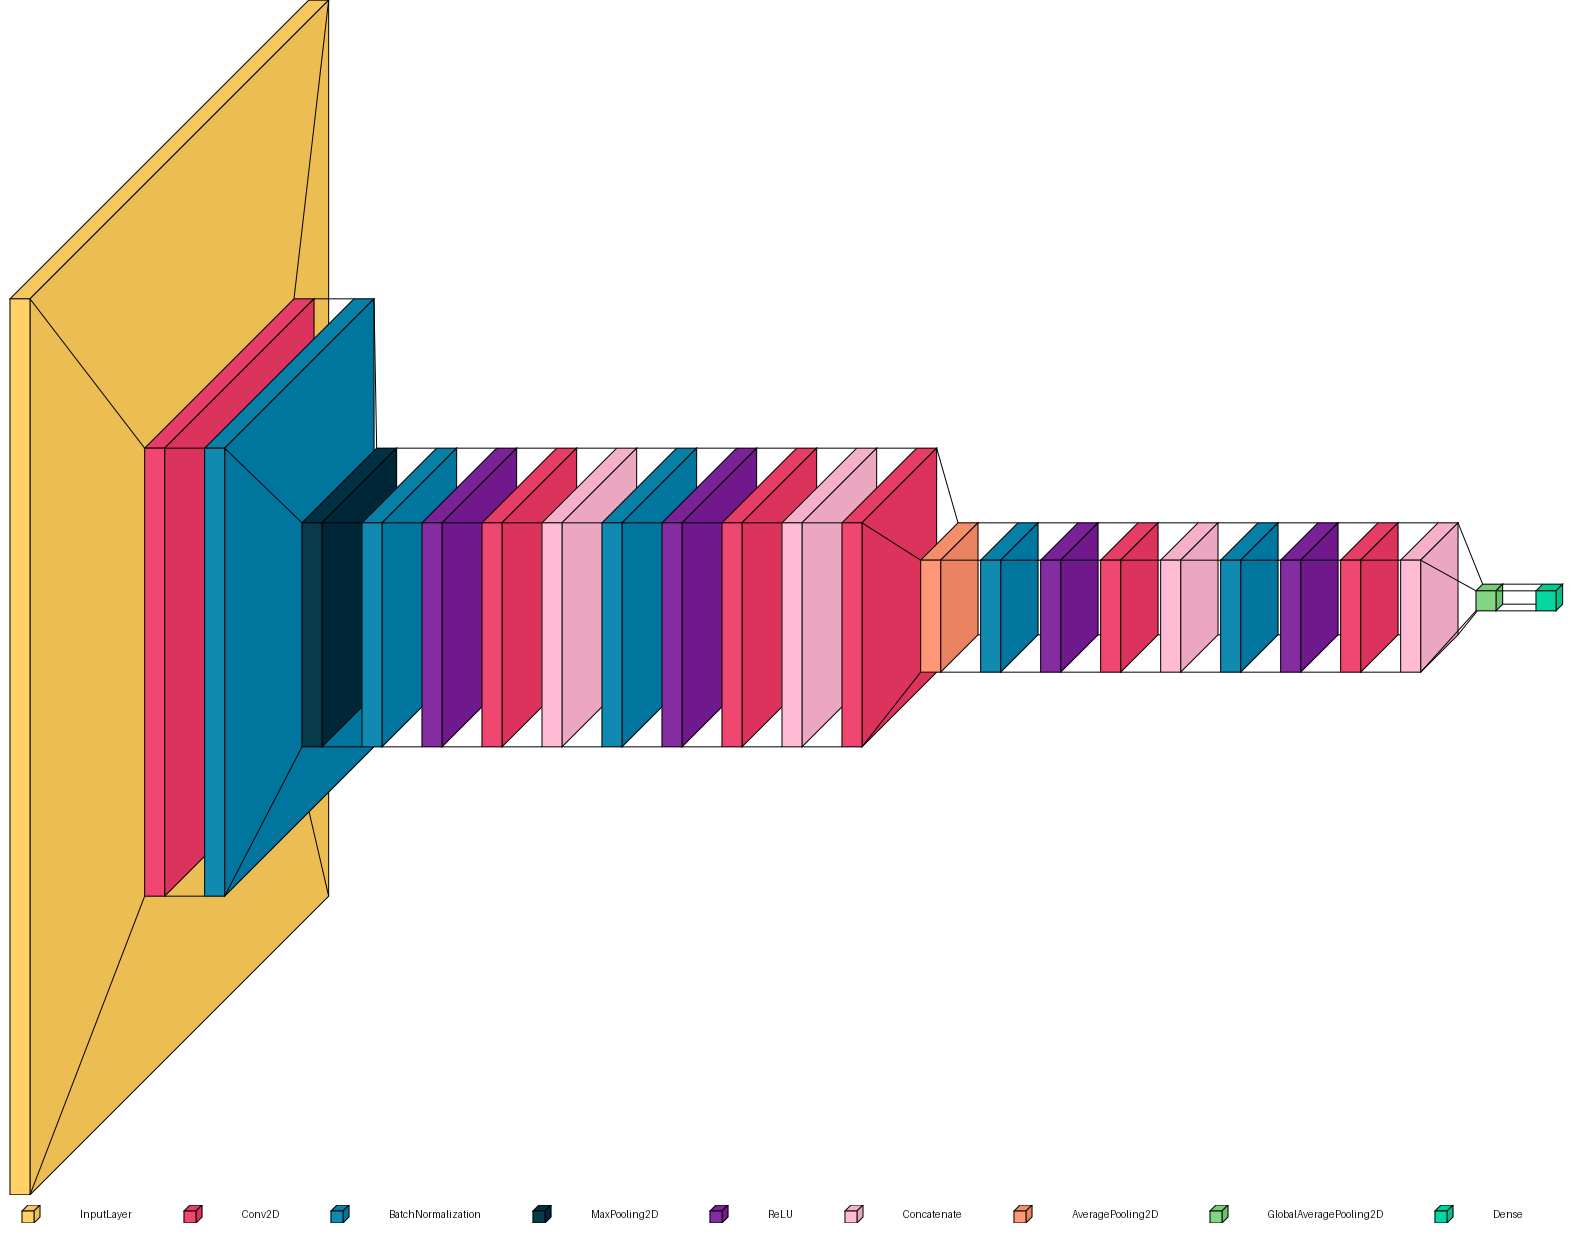

In [4]:
visualkeras.layered_view(
    baseline_model,
    legend=True,
    spacing=40, 
    draw_volume=True,  
    to_file="baseline_model_keras.png"
)


In [5]:
X, y = lpd(
    input_dir='./data', 
    output_dir='./processed_data', 
    augment_chance=0.15,
)

resized file count (hatchback) : 602
resized file count (moped) : 600
resized file count (pickup) : 1689
resized file count (seden) : 1222
resized file count (suv) : 680
balanced file count (hatchback) : 600
balanced file count (moped) : 600
balanced file count (pickup) : 600
balanced file count (seden) : 600
balanced file count (suv) : 600
augmented file count (hatchback) : 600
augmented file count (moped) : 600
augmented file count (pickup) : 600
augmented file count (seden) : 600
augmented file count (suv) : 600
Deleted processed_data


In [6]:
print(X.shape)
print(y.shape)

(3000, 224, 224, 3)
(3000,)


In [7]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [8]:
from collections import Counter
class_counts = Counter(y_train)

for class_label, count in class_counts.items():
    print(f"Class {class_label}: {count}")

Class 0: 487
Class 1: 459
Class 2: 478
Class 3: 487
Class 4: 489


In [9]:
model_one = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
)

baseline_model.save("models/baseline_model.keras")

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 83s 963ms/step - accuracy: 0.3432 - loss: 1.4831 - val_accuracy: 0.2150 - val_loss: 1.7514
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 64s 730ms/step - accuracy: 0.5848 - loss: 1.0076 - val_accuracy: 0.2350 - val_loss: 1.7117
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 49s 655ms/step - accuracy: 0.6598 - loss: 0.8784 - val_accuracy: 0.2350 - val_loss: 2.3694
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 55s 739ms/step - accuracy: 0.6776 - loss: 0.8058 - val_accuracy: 0.2817 - val_loss: 1.8836
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 70s 940ms/step - accuracy: 0.7099 - loss: 0.7399 - val_accuracy: 0.3200 - val_loss: 1.6114
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 78s 881ms/step - accuracy: 0.7402 - loss: 0.6729 - val_accuracy: 0.4200 - val_loss: 1.5068
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 73s 981ms/step - accuracy: 0.7629 - loss: 0.6379 - val_accuracy: 0.2100 - val_loss: 3.5827
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.7683 - loss: 0.6078 - val_accurac

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step


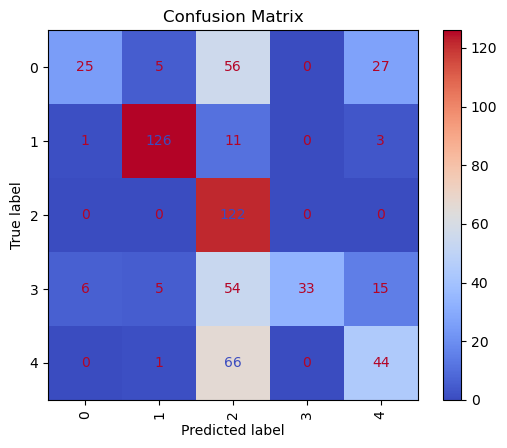

In [ ]:
y_pred = baseline_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

matrix = confusion_matrix(y_test, y_pred_classes)
cm_d = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=np.unique(y_test))

cm_d.plot(cmap='coolwarm', xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()

In [11]:
test_loss, test_accuracy = baseline_model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.5581 - loss: 1.2343
Test Loss: 1.1752382516860962, Test Accuracy: 0.5833333134651184


In [12]:
def plot_training_history(model):
    # Plot accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.xlim(0, 10)
    plt.ylim(0, 1)
    plt.plot(model.history['accuracy'], label='Train Accuracy')
    plt.plot(model.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(False)

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(model.history['loss'], label='Train Loss')
    plt.plot(model.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(False)
    plt.xlim(0, 10)
    plt.ylim(0, 5)

    
    plt.tight_layout()
    plt.show()

# Call the function to visualize
#plot_training_history(model_one)

In [13]:
data = pd.DataFrame(model_one.history)
data

,accuracy,loss,val_accuracy,val_loss
0,0.441250,1.315777,0.215000,1.751409
1,0.594167,0.993981,0.235000,1.711707
2,0.661667,0.863992,0.235000,2.369392
3,0.673750,0.820222,0.281667,1.883597
4,0.722500,0.734354,0.320000,1.611380
5,0.738750,0.674201,0.420000,1.506847
6,0.772083,0.614251,0.210000,3.582662
7,0.777500,0.599897,0.405000,3.933128
8,0.805417,0.546940,0.381667,2.664762
9,0.823750,0.476163,0.583333,1.175238


In [14]:
def create_model_with_he_init(input_shape=(224, 224, 3), num_classes=5):
    """
    Creates a DenseNet-based model with He initialization.

    Args:
        input_shape (tuple): Shape of the input images.
        num_classes (int): Number of output classes.

    Returns:
        tf.keras.Model: Model with He initialization.
    """
    inputs = layers.Input(shape=input_shape)

    # Initial convolution
    x = layers.Conv2D(16, (7, 7), strides=2, padding="same", activation="relu",
                      kernel_initializer=initializers.HeNormal())(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding="same")(x)

    # Dense Block 1
    for _ in range(2):  # Two layers in the block
        y = layers.BatchNormalization()(x)
        y = layers.ReLU()(y)
        y = layers.Conv2D(16, (3, 3), padding="same", kernel_initializer=initializers.HeNormal())(y)
        x = layers.Concatenate()([x, y])  # Dense connection

    # Transition Layer
    x = layers.Conv2D(32, (1, 1), activation="relu", kernel_initializer=initializers.HeNormal())(x)
    x = layers.AveragePooling2D((2, 2))(x)

    # Dense Block 2
    for _ in range(2):  # Two layers in the block
        y = layers.BatchNormalization()(x)
        y = layers.ReLU()(y)
        y = layers.Conv2D(32, (3, 3), padding="same", kernel_initializer=initializers.HeNormal())(y)
        x = layers.Concatenate()([x, y])  # Dense connection

    # Transition to Output
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation="softmax", kernel_initializer=initializers.HeNormal())(x)

    model = models.Model(inputs, outputs)
    return model


In [15]:
model_with_he = create_model_with_he_init()

model_with_he.compile(
    optimizer="adam", 
    loss="sparse_categorical_crossentropy", 
    metrics=["accuracy"],
)

# Summary of the model
model_with_he.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 112, 112,  │      2,368 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │         64 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │         64 │ max_pooling2d_1[… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 56, 56,    │      2,320 │ re_lu_4[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 56, 56,    │          0 │ max_pooling2d_1[… │
│ (Concatenate)       │ 32)               │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        128 │ concatenate_4[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_5 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 56, 56,    │      4,624 │ re_lu_5[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 56, 56,    │          0 │ concatenate_4[0]… │
│ (Concatenate)       │ 48)               │            │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 56, 56,    │      1,568 │ concatenate_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_1 │ (None, 28, 28,    │          0 │ conv2d_9[0][0]    │
│ (AveragePooling2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ average_pooling2… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_6 (ReLU)      │ (None, 28, 28,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 28, 28,    │      9,248 │ re_lu_6[0][0]   

 Total params: 39,717 (155.14 KB)

 Trainable params: 39,397 (153.89 KB)

 Non-trainable params: 320 (1.25 KB)

In [16]:
model_two = model_with_he.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
)

model_with_he.save('./models/model_with_he.keras')

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 67s 827ms/step - accuracy: 0.3606 - loss: 1.4743 - val_accuracy: 0.1983 - val_loss: 1.6292
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 62s 811ms/step - accuracy: 0.5407 - loss: 1.0768 - val_accuracy: 0.2467 - val_loss: 1.6937
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 53s 707ms/step - accuracy: 0.6291 - loss: 0.9216 - val_accuracy: 0.3267 - val_loss: 1.4618
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 69s 911ms/step - accuracy: 0.6507 - loss: 0.8808 - val_accuracy: 0.3033 - val_loss: 1.6806
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 63s 836ms/step - accuracy: 0.6934 - loss: 0.7645 - val_accuracy: 0.5567 - val_loss: 1.0692
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 74s 728ms/step - accuracy: 0.7270 - loss: 0.7115 - val_accuracy: 0.4783 - val_loss: 1.9925
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.7780 - loss: 0.6240 - val_accuracy: 0.5950 - val_loss: 1.0074
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 61s 817ms/step - accuracy: 0.7723 - loss: 0.5976 - val_accurac

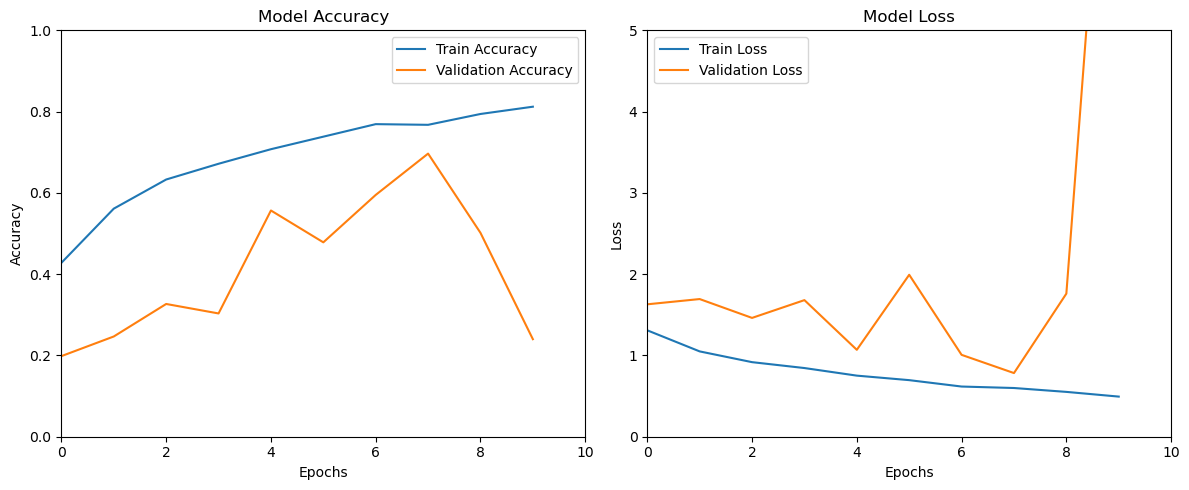

In [17]:
plot_training_history(model_two)

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step


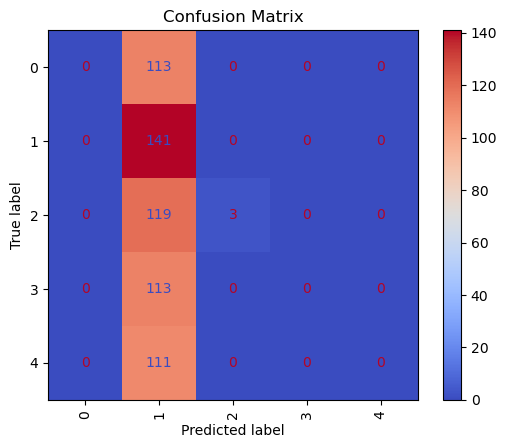

In [ ]:
y_pred = model_with_he.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

matrix = confusion_matrix(y_test, y_pred_classes)
cm_d = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=np.unique(y_test))

cm_d.plot(cmap='coolwarm', xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()

In [19]:
pd.DataFrame(model_two.history)

,accuracy,loss,val_accuracy,val_loss
0,0.427917,1.309063,0.198333,1.629171
1,0.561250,1.049779,0.246667,1.693737
2,0.632917,0.917466,0.326667,1.461825
3,0.671667,0.844948,0.303333,1.680624
4,0.707500,0.751595,0.556667,1.069155
5,0.738333,0.696107,0.478333,1.992530
6,0.769167,0.617429,0.595000,1.007387
7,0.767500,0.599320,0.696667,0.783200
8,0.794167,0.551592,0.501667,1.760656
9,0.812083,0.493675,0.240000,10.258595


In [20]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes = np.unique(y_train),
    y = y_train,
)
weights_dict = dict(enumerate(class_weights))

print("class Weights: ", weights_dict)

class Weights:  {0: 0.9856262833675564, 1: 1.0457516339869282, 2: 1.00418410041841, 3: 0.9856262833675564, 4: 0.9815950920245399}


In [21]:
model_two_with_weights = model_with_he.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size = 32,
    class_weight=weights_dict
)

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 82s 998ms/step - accuracy: 0.8166 - loss: 0.4876 - val_accuracy: 0.3817 - val_loss: 4.3429
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.8422 - loss: 0.4329 - val_accuracy: 0.6367 - val_loss: 1.2807
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 69s 917ms/step - accuracy: 0.8486 - loss: 0.3955 - val_accuracy: 0.2883 - val_loss: 3.3642
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 63s 827ms/step - accuracy: 0.8613 - loss: 0.3907 - val_accuracy: 0.3767 - val_loss: 2.7383
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 52s 694ms/step - accuracy: 0.8430 - loss: 0.4155 - val_accuracy: 0.6850 - val_loss: 1.0629
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 50s 673ms/step - accuracy: 0.8890 - loss: 0.2969 - val_accuracy: 0.5983 - val_loss: 1.2141
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 62s 821ms/step - accuracy: 0.8779 - loss: 0.3211 - val_accuracy: 0.5617 - val_loss: 1.5412
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 71s 934ms/step - accuracy: 0.8940 - loss: 0.2912 - val_accurac

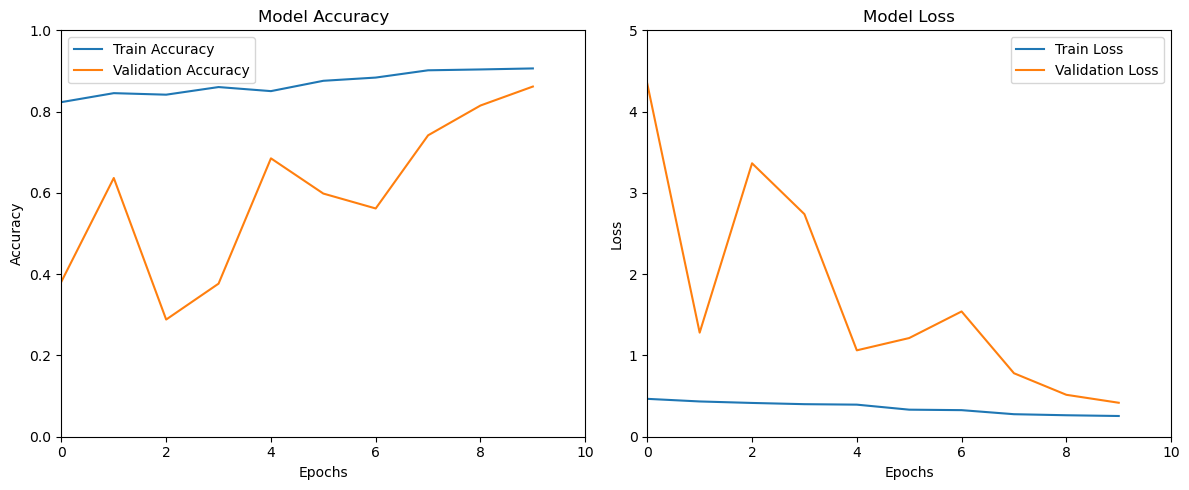

In [22]:
plot_training_history(model_two_with_weights)

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step


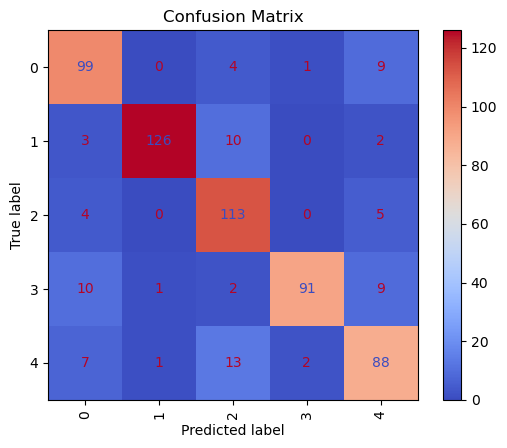

In [ ]:
y_pred = model_with_he.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

matrix = confusion_matrix(y_test, y_pred_classes)
cm_d = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=np.unique(y_test))

cm_d.plot(cmap='coolwarm', xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()

In [24]:
pd.DataFrame(model_two_with_weights.history)

,accuracy,loss,val_accuracy,val_loss
0,0.823333,0.465988,0.381667,4.342875
1,0.845417,0.433886,0.636667,1.280697
2,0.841667,0.415555,0.288333,3.364185
3,0.860417,0.400462,0.376667,2.738323
4,0.850417,0.394635,0.685000,1.062889
5,0.875833,0.332814,0.598333,1.214088
6,0.883750,0.326957,0.561667,1.541217
7,0.901667,0.277051,0.741667,0.781057
8,0.903750,0.264149,0.815000,0.515769
9,0.906250,0.254985,0.861667,0.417873


In [25]:
def train_with_learning_rate(lr, trial_name, class_weights_dict):
    """
    Train the model with a specific learning rate.

    Args:
        lr (float): Learning rate to use.
        trial_name (str): Name of the trial for saving results.

    Returns:
        History object of the trained model.
    """
    print(f"Training with learning rate: {lr}")

    # Define optimizer with specific learning rate
    optimizer = Adam(learning_rate=lr)
    model_with_weights = create_model_with_he_init()
    model_with_weights.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    lr_model = model_with_weights.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=10,
        batch_size=32,
        class_weight=class_weights_dict 
    )

    model_with_weights.save(f"models/model_with_lr_{trial_name}.keras")

    return lr_model

In [26]:
history_high = train_with_learning_rate(0.01, "high", weights_dict)
history_medium = train_with_learning_rate(0.001, "medium", weights_dict)
history_low = train_with_learning_rate(0.0001, "low", weights_dict)

Training with learning rate: 0.01
Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 71s 848ms/step - accuracy: 0.2706 - loss: 2.0622 - val_accuracy: 0.1883 - val_loss: 4.8939
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 59s 791ms/step - accuracy: 0.4318 - loss: 1.2924 - val_accuracy: 0.2267 - val_loss: 5.3829
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 65s 866ms/step - accuracy: 0.5491 - loss: 1.0205 - val_accuracy: 0.1917 - val_loss: 11.5394
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 75s 764ms/step - accuracy: 0.5879 - loss: 0.9857 - val_accuracy: 0.4167 - val_loss: 2.8359
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 59s 785ms/step - accuracy: 0.6540 - loss: 0.8224 - val_accuracy: 0.4517 - val_loss: 1.7244
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 60s 802ms/step - accuracy: 0.6460 - loss: 0.8609 - val_accuracy: 0.4800 - val_loss: 1.4510
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 77s 729ms/step - accuracy: 0.6835 - loss: 0.7598 - val_accuracy: 0.3083 - val_loss: 2.3256
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 58s 769ms/step - accurac

In [27]:
def plot_learning_rate_trials(history_high, history_medium, history_low):
    """
    Plot training and validation accuracy/loss for different learning rates as side-by-side subplots.

    Args:
        history_high, history_medium, history_low: History objects from each trial.
    """
    # Extract accuracy and loss
    histories = [("High LR", history_high), ("Medium LR", history_medium), ("Low LR", history_low)]

    # Create color map
    colors = cm.tab10(range(len(histories)))  # Use a colormap for consistent colors
    
    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # Two side-by-side subplots

    # Plot accuracy
    for idx, (name, history) in enumerate(histories):
        axes[0].plot(history.history['val_accuracy'], label=f"Val Accuracy ({name})", color=colors[idx])
        axes[0].plot(history.history['accuracy'], label=f"Train Accuracy ({name})", linestyle="dashed", color=colors[idx])
    axes[0].set_title("Accuracy Comparison")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_xlim(0, 10)
    axes[0].legend()

    # Plot loss
    for idx, (name, history) in enumerate(histories):
        axes[1].plot(history.history['val_loss'], label=f"Val Loss ({name})", color=colors[idx])
        axes[1].plot(history.history['loss'], label=f"Train Loss ({name})", linestyle="dashed", color=colors[idx])
    axes[1].set_title("Loss Comparison")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Loss")
    axes[1].set_xlim(0, 10)
    axes[1].legend()

    # Adjust spacing
    plt.tight_layout()
    plt.show()


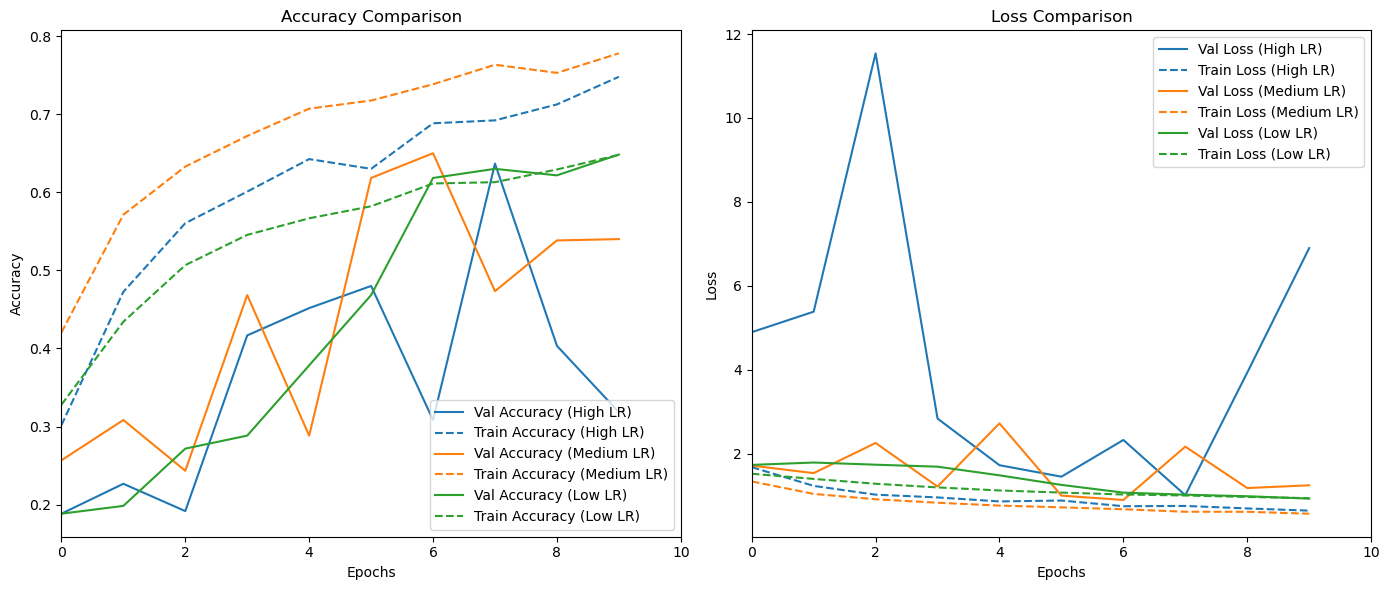

In [30]:
plot_learning_rate_trials(history_high, history_medium, history_low)

19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 270ms/step


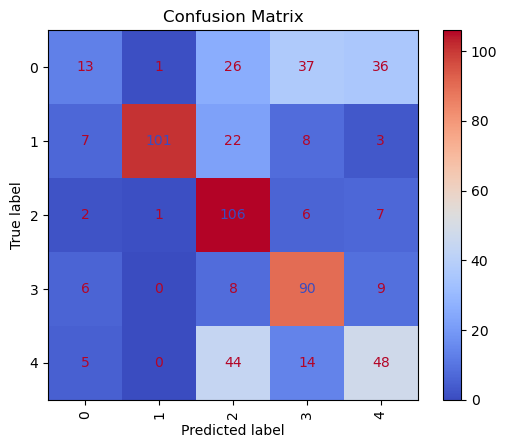

In [ ]:
model_three = models.load_model("models/model_with_lr_low_lr.keras")

y_pred = model_three.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

matrix = confusion_matrix(y_test, y_pred_classes)
cm_d = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=np.unique(y_test))

cm_d.plot(cmap='coolwarm', xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()

In [31]:
pd.DataFrame(data=history_high.history)

,accuracy,loss,val_accuracy,val_loss
0,0.301667,1.678205,0.188333,4.893892
1,0.472500,1.231535,0.226667,5.382916
2,0.560417,1.022309,0.191667,11.539366
3,0.600833,0.956416,0.416667,2.835875
4,0.642500,0.861300,0.451667,1.724365
5,0.630000,0.882640,0.480000,1.451010
6,0.688333,0.747250,0.308333,2.325592
7,0.692083,0.753629,0.636667,1.009673
8,0.712500,0.694408,0.403333,3.931406
9,0.747917,0.641231,0.318333,6.897249


In [32]:
pd.DataFrame(data=history_medium.history)

,accuracy,loss,val_accuracy,val_loss
0,0.420417,1.337508,0.256667,1.714945
1,0.571250,1.040799,0.308333,1.535328
2,0.632917,0.912556,0.243333,2.254288
3,0.672083,0.830472,0.468333,1.216274
4,0.707083,0.761854,0.288333,2.721157
5,0.717500,0.720153,0.618333,0.999862
6,0.738333,0.674382,0.650000,0.895488
7,0.763333,0.615611,0.473333,2.167311
8,0.752917,0.614293,0.538333,1.179705
9,0.777917,0.568573,0.540000,1.245705


In [33]:
pd.DataFrame(data=history_low.history)

,accuracy,loss,val_accuracy,val_loss
0,0.327917,1.521016,0.188333,1.731751
1,0.434167,1.397408,0.198333,1.788210
2,0.506667,1.282304,0.271667,1.736342
3,0.545417,1.195327,0.288333,1.689045
4,0.566667,1.122287,0.378333,1.482878
5,0.582083,1.072056,0.468333,1.255153
6,0.611250,1.026158,0.618333,1.070889
7,0.612917,1.002546,0.630000,1.021977
8,0.629167,0.967833,0.621667,0.984753
9,0.647917,0.939095,0.648333,0.928463


In [34]:
def create_model_with_dropout(input_shape=(224, 224, 3), num_classes=5, dropout_rate=0.3):
    """
    Creates a DenseNet-based model with He initialization and dropout.

    Args:
        input_shape (tuple): Shape of the input images.
        num_classes (int): Number of output classes.

    Returns:
        tf.keras.Model: Model with He initialization and dropout.
    """
    inputs = layers.Input(shape=input_shape)

    # Initial convolution
    x = layers.Conv2D(16, (7, 7), strides=2, padding="same", activation="relu",
                      kernel_initializer=initializers.HeNormal())(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding="same")(x)

    # Dense Block 1
    for _ in range(2):  # Two layers in the block
        y = layers.BatchNormalization()(x)
        y = layers.ReLU()(y)
        y = layers.Conv2D(16, (3, 3), padding="same", kernel_initializer=initializers.HeNormal())(y)
        x = layers.Concatenate()([x, y]) 
    
    # dropout layer
    x = layers.Dropout(dropout_rate)(x)

    # Transition Layer
    x = layers.Conv2D(32, (1, 1), activation="relu", kernel_initializer=initializers.HeNormal())(x)
    x = layers.AveragePooling2D((2, 2))(x)

    # Dense Block 2
    for _ in range(2):  # Two layers in the block
        y = layers.BatchNormalization()(x)
        y = layers.ReLU()(y)
        y = layers.Conv2D(32, (3, 3), padding="same", kernel_initializer=initializers.HeNormal())(y)
        x = layers.Concatenate()([x, y])  # Dense connection

    x = layers.Dropout(dropout_rate)(x)
    
    # Transition to Output
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation="softmax", kernel_initializer=initializers.HeNormal())(x)

    model = models.Model(inputs, outputs)
    return model


In [35]:
dropout_rates = [0.1, 0.2, 0.3]
histories = {}

for rate in dropout_rates:
    print(f"Training model with dropout rate: {rate}")
    model = create_model_with_dropout(dropout_rate=rate)

    # Compile the model
    optimiser = Adam(learning_rate=0.0001)
    model.compile(optimizer=optimiser, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    # Train the model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=10,
        batch_size=32,
        class_weight=weights_dict
    )

    # Save history for later comparison
    histories[f"Dropout {rate}"] = history

Training model with dropout rate: 0.1
Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 59s 711ms/step - accuracy: 0.2417 - loss: 2.0055 - val_accuracy: 0.1883 - val_loss: 1.7704
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 52s 686ms/step - accuracy: 0.3643 - loss: 1.4793 - val_accuracy: 0.2950 - val_loss: 1.5810
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 50s 666ms/step - accuracy: 0.4287 - loss: 1.3612 - val_accuracy: 0.3517 - val_loss: 1.4734
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 48s 638ms/step - accuracy: 0.5018 - loss: 1.2466 - val_accuracy: 0.3900 - val_loss: 1.4052
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 81s 622ms/step - accuracy: 0.5105 - loss: 1.1934 - val_accuracy: 0.4367 - val_loss: 1.3768
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 47s 628ms/step - accuracy: 0.5519 - loss: 1.1257 - val_accuracy: 0.4783 - val_loss: 1.2736
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 47s 632ms/step - accuracy: 0.5710 - loss: 1.0779 - val_accuracy: 0.5600 - val_loss: 1.1435
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 48s 638ms/step - accu

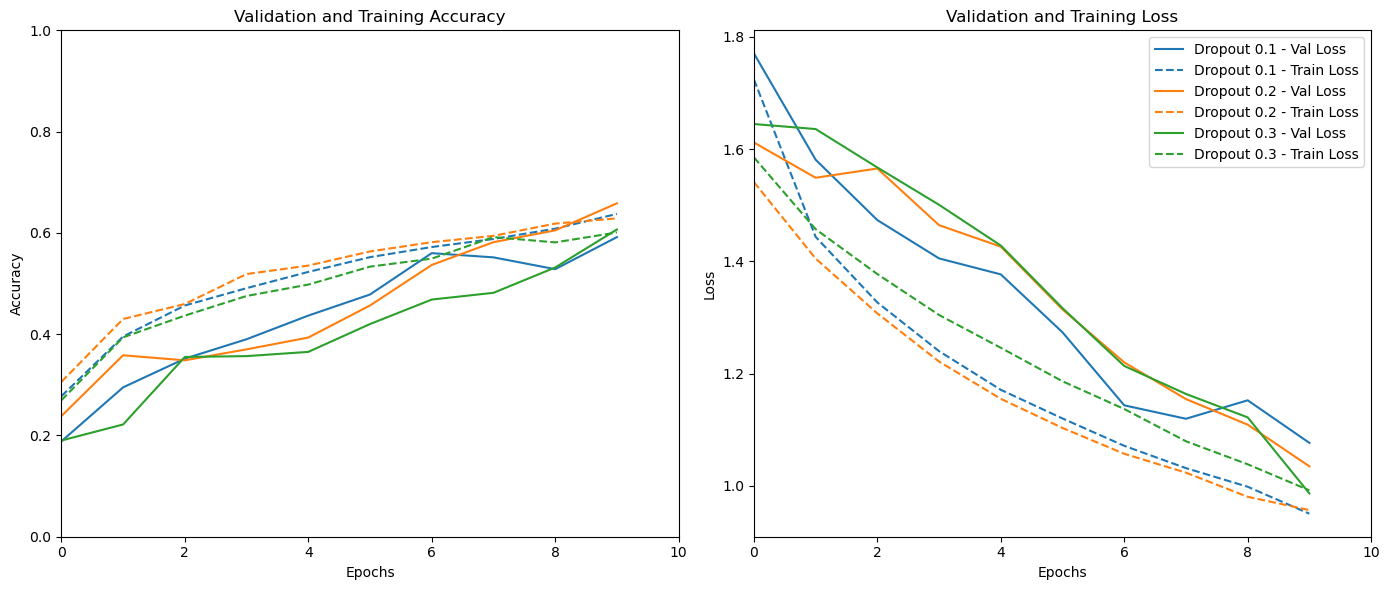

In [36]:
def plot_dropout_comparison(histories):
    """
    Plots training and validation accuracy/loss for models with different dropout rates,
    ensuring consistent colors between training and validation lines.

    Args:
        histories (dict): Dictionary containing histories of models with different dropout rates.
    """
    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Define a colormap
    colors = cm.tab10(range(len(histories)))

    # Plot each history
    for idx, (label, history) in enumerate(histories.items()):
        # Get the color for this dropout rate
        color = colors[idx]

        # Accuracy
        axes[0].plot(history.history['val_accuracy'], label=f"{label} - Val Accuracy", color=color)
        axes[0].plot(history.history['accuracy'], linestyle="dashed", label=f"{label} - Train Accuracy", color=color)

        # Loss
        axes[1].plot(history.history['val_loss'], label=f"{label} - Val Loss", color=color)
        axes[1].plot(history.history['loss'], linestyle="dashed", label=f"{label} - Train Loss", color=color)

    # Accuracy plot formatting
    axes[0].set_title("Validation and Training Accuracy")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Accuracy")

    axes[0].set_xlim(0, 10)
    axes[0].set_ylim(0, 1)

    # Loss plot formatting
    axes[1].set_title("Validation and Training Loss")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Loss")
    axes[1].set_xlim(0, 10)
    axes[1].legend()

    # Adjust layout
    plt.tight_layout()
    plt.show()

# Example usage:
plot_dropout_comparison(histories)


In [37]:
pd.DataFrame(histories['Dropout 0.1'].history)

,accuracy,loss,val_accuracy,val_loss
0,0.277500,1.723989,0.188333,1.770429
1,0.395417,1.443641,0.295000,1.581044
2,0.456667,1.326735,0.351667,1.473447
3,0.490833,1.239985,0.390000,1.405192
4,0.522917,1.171191,0.436667,1.376778
5,0.552083,1.120116,0.478333,1.273569
6,0.572083,1.071425,0.560000,1.143538
7,0.587917,1.031667,0.551667,1.119606
8,0.608333,0.998528,0.528333,1.152496
9,0.637500,0.950514,0.591667,1.076647


In [38]:
pd.DataFrame(histories['Dropout 0.2'].history)

,accuracy,loss,val_accuracy,val_loss
0,0.305833,1.541207,0.238333,1.611670
1,0.430000,1.404973,0.358333,1.548865
2,0.459583,1.307256,0.348333,1.565363
3,0.518750,1.221515,0.370000,1.464390
4,0.535417,1.155153,0.393333,1.426152
5,0.563333,1.103233,0.456667,1.314284
6,0.581667,1.057220,0.536667,1.220041
7,0.594167,1.023605,0.581667,1.154688
8,0.618333,0.980616,0.605000,1.109122
9,0.628750,0.956946,0.658333,1.034857


In [39]:
pd.DataFrame(histories['Dropout 0.3'].history)

,accuracy,loss,val_accuracy,val_loss
0,0.269583,1.585226,0.190000,1.644525
1,0.393750,1.457293,0.221667,1.635617
2,0.436667,1.377313,0.355000,1.567163
3,0.475417,1.304377,0.356667,1.500645
4,0.497917,1.246027,0.365000,1.428108
5,0.533333,1.186375,0.420000,1.316671
6,0.549167,1.136999,0.468333,1.213652
7,0.591667,1.079533,0.481667,1.163813
8,0.581250,1.038535,0.531667,1.122089
9,0.600833,0.992091,0.606667,0.986558


In [40]:
model_four = create_model_with_dropout(dropout_rate=0.2)

# Compile the model
optimiser = Adam(learning_rate=0.0001)
model_four.compile(optimizer=optimiser, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model_four.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

model_four.save('models/model_four_dropout.keras')



Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 57s 689ms/step - accuracy: 0.2173 - loss: 1.5916 - val_accuracy: 0.1883 - val_loss: 1.6470
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 50s 649ms/step - accuracy: 0.3577 - loss: 1.4679 - val_accuracy: 0.2550 - val_loss: 1.6344
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 45s 601ms/step - accuracy: 0.4321 - loss: 1.3584 - val_accuracy: 0.3333 - val_loss: 1.6041
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 46s 610ms/step - accuracy: 0.4865 - loss: 1.2796 - val_accuracy: 0.3167 - val_loss: 1.5979
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 45s 598ms/step - accuracy: 0.5452 - loss: 1.1993 - val_accuracy: 0.3500 - val_loss: 1.4078
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 45s 601ms/step - accuracy: 0.5733 - loss: 1.1305 - val_accuracy: 0.4917 - val_loss: 1.2162
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 46s 606ms/step - accuracy: 0.5968 - loss: 1.0725 - val_accuracy: 0.5700 - val_loss: 1.1054
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 46s 608ms/step - accuracy: 0.6048 - loss: 1.0592 - val_accu

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step


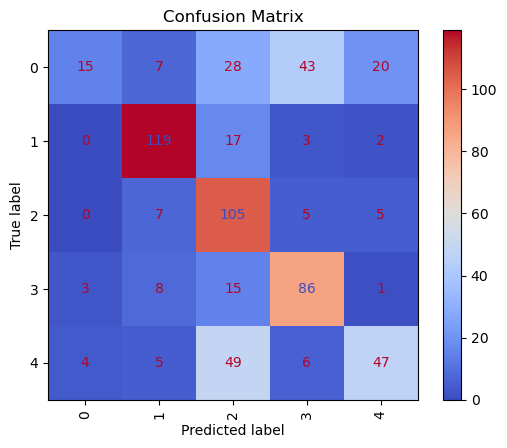

In [41]:
y_pred = model_four.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
cm_d = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))

cm_d.plot(cmap='coolwarm', xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()

## Experiment 5 - Increased Model Complexity

Increasing complexity through more dense blocks, increased kernel counts.

In [42]:
def complex_model(input_shape=(224, 224, 3), num_classes=5, dropout_rate=0.2):
    inputs = layers.Input(shape=input_shape)

    # Initial convolution
    x = layers.Conv2D(32, (3, 3), strides=2, padding="same", activation="relu",
                      kernel_initializer=initializers.HeNormal())(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding="same")(x)

    # Dense Block 1
    for _ in range(3):
        y = layers.Conv2D(32, (1, 1), kernel_initializer=initializers.HeNormal())(x)
        y = layers.BatchNormalization()(y)
        y = layers.ReLU()(y)
        y = layers.Conv2D(32, (3, 3), padding="same", kernel_initializer=initializers.HeNormal())(y)
        x = layers.Concatenate()([x, y])

    x = layers.Dropout(dropout_rate)(x)

    # Transition Layer 1
    x = layers.Conv2D(64, (1, 1), activation="relu", kernel_initializer=initializers.HeNormal())(x)
    x = layers.AveragePooling2D((2, 2))(x)

    # Dense Block 2
    for _ in range(3):
        y = layers.Conv2D(64, (1, 1), kernel_initializer=initializers.HeNormal())(x)
        y = layers.BatchNormalization()(y)
        y = layers.ReLU()(y)
        y = layers.Conv2D(64, (3, 3), padding="same", kernel_initializer=initializers.HeNormal())(y)
        x = layers.Concatenate()([x, y])

    x = layers.Dropout(dropout_rate)(x)

    # Transition to Output
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation="softmax", kernel_initializer=initializers.HeNormal())(x)

    model = models.Model(inputs, outputs)
    return model


In [43]:
model_five = complex_model()

optimiser = Adam(learning_rate=0.0001)
model_five.compile(
    optimizer=optimiser,
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']    
)

model_five.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_54 (Conv2D)  │ (None, 112, 112,  │        896 │ input_layer_9[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ conv2d_54[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_55 (Conv2D)  │ (None, 56, 56,    │      1,056 │ max_pooling2d_9[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        128 │ conv2d_55[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_36 (ReLU)     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_56 (Conv2D)  │ (None, 56, 56,    │      9,248 │ re_lu_36[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_36      │ (None, 56, 56,    │          0 │ max_pooling2d_9[… │
│ (Concatenate)       │ 64)               │            │ conv2d_56[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_57 (Conv2D)  │ (None, 56, 56,    │      2,080 │ concatenate_36[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        128 │ conv2d_57[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_37 (ReLU)     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_58 (Conv2D)  │ (None, 56, 56,    │      9,248 │ re_lu_37[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_37      │ (None, 56, 56,    │          0 │ concatenate_36[0… │
│ (Concatenate)       │ 96)               │            │ conv2d_58[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_59 (Conv2D)  │ (None, 56, 56,    │      3,104 │ concatenate_37[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        128 │ conv2d_59[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_38 (ReLU)     │ (None, 56, 56,    │          0 │ batch_normalizat

 Total params: 181,253 (708.02 KB)

 Trainable params: 180,613 (705.52 KB)

 Non-trainable params: 640 (2.50 KB)

/opt/anaconda3/lib/python3.11/site-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


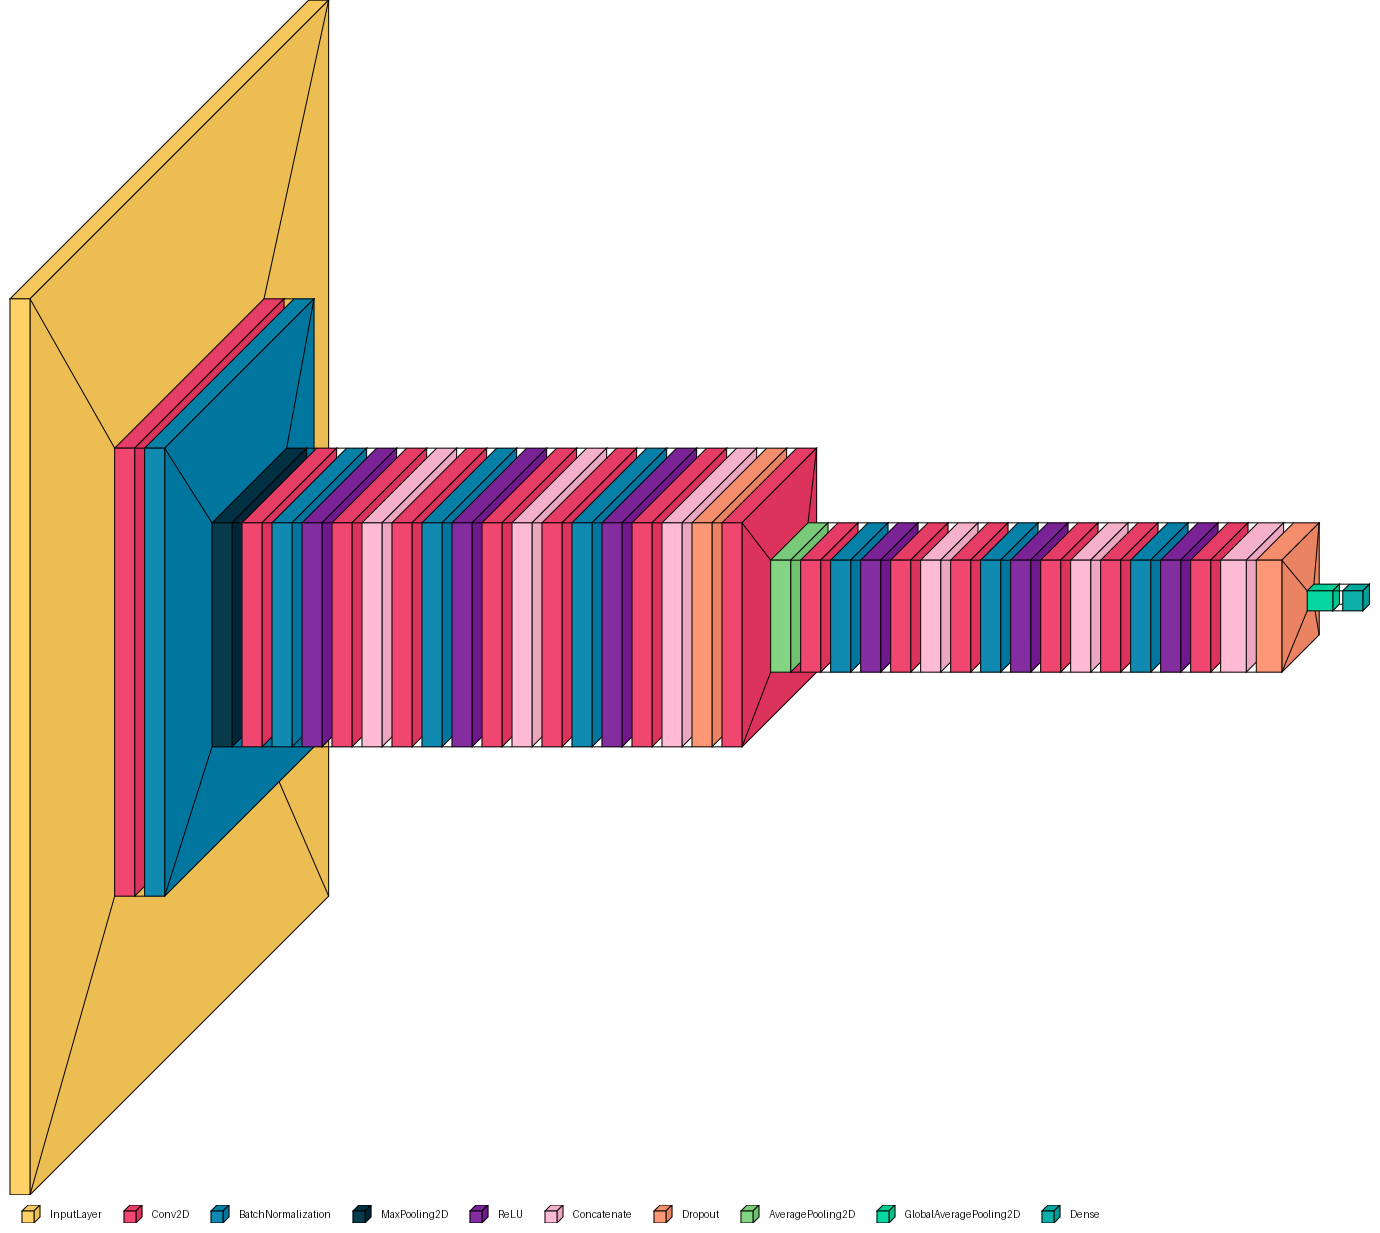

In [44]:
visualkeras.layered_view(
    model_five,
    to_file='model_five_visual.png',
    legend=True,
)


In [45]:
history = model_five.fit(
    X_train, y_train,
    validation_data =(X_test, y_test),
    epochs=10,
    batch_size=32
)

model_five.save('models/complex_model.keras')

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.3009 - loss: 1.5505 - val_accuracy: 0.2333 - val_loss: 1.6408
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.4785 - loss: 1.2949 - val_accuracy: 0.2667 - val_loss: 2.0959
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.5327 - loss: 1.1284 - val_accuracy: 0.2350 - val_loss: 2.7529
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.6167 - loss: 0.9918 - val_accuracy: 0.2867 - val_loss: 2.6039
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.6510 - loss: 0.8982 - val_accuracy: 0.2700 - val_loss: 2.6219
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.6681 - loss: 0.8415 - val_accuracy: 0.2867 - val_loss: 2.4849
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.6865 - loss: 0.8008 - val_accuracy: 0.3967 - val_loss: 1.7410
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.7131 - loss: 0.7470 - val_accuracy: 0.5100 - v

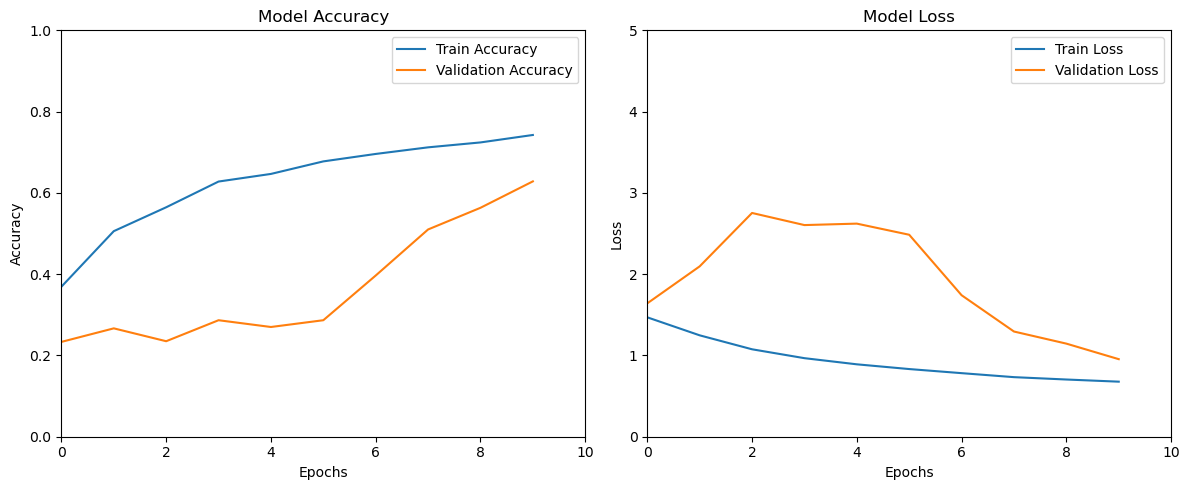

In [46]:
plot_training_history(history)

In [47]:
pd.DataFrame(history.history)

,accuracy,loss,val_accuracy,val_loss
0,0.369167,1.468990,0.233333,1.640841
1,0.505833,1.247542,0.266667,2.095949
2,0.564583,1.075797,0.235000,2.752941
3,0.627917,0.966455,0.286667,2.603920
4,0.646667,0.890824,0.270000,2.621863
5,0.677500,0.832532,0.286667,2.484934
6,0.695833,0.782141,0.396667,1.740980
7,0.712083,0.732942,0.510000,1.294260
8,0.724167,0.703877,0.563333,1.145439
9,0.742500,0.677380,0.628333,0.954187


19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 262ms/step


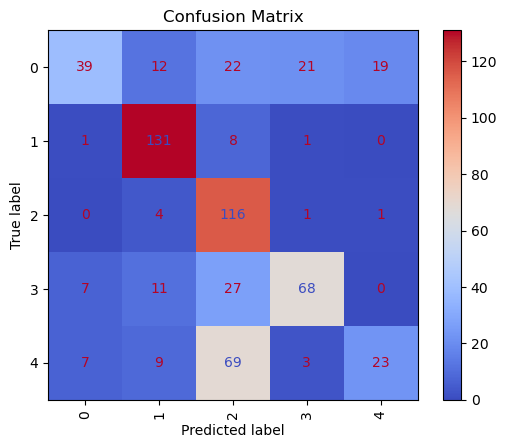

In [48]:
y_pred = model_five.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
cm_d = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))

cm_d.plot(cmap='coolwarm', xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()

In [49]:
import data_loader
from importlib import reload
reload(data_loader)
from data_loader import load_processed_data as lpd

In [50]:
X_unbalanced, y_unbalanced = lpd('./data', balance=False)
label_encoder = LabelEncoder()
y_unbalanced = label_encoder.fit_transform(y_unbalanced)

X_train_unbalanced, X_test_unbalanced, y_train_unbalanced, y_test_unbalanced = train_test_split(
    X_unbalanced, y_unbalanced, 
    test_size=0.2, 
    random_state=42
)


resized file count (hatchback) : 602
resized file count (moped) : 600
resized file count (pickup) : 1689
resized file count (seden) : 1222
resized file count (suv) : 680
augmented file count (hatchback) : 602
augmented file count (moped) : 600
augmented file count (pickup) : 1689
augmented file count (seden) : 1222
augmented file count (suv) : 680
Deleted processed_data


In [51]:
class_weights_unbalanced = compute_class_weight(
    class_weight='balanced',
    classes = np.unique(y_train_unbalanced),
    y = y_train_unbalanced,
)
weights_dict_unbalanced = dict(enumerate(class_weights_unbalanced))

print("class Weights: ", weights_dict_unbalanced)

class Weights:  {0: 1.6008350730688936, 1: 1.681578947368421, 2: 0.5536462093862816, 3: 0.7913312693498452, 4: 1.4069724770642202}


In [52]:
model_six = create_model_with_dropout(dropout_rate=0.2)

# Compile the model
optimiser = Adam(learning_rate=0.0001)
model_six.compile(optimizer=optimiser, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history = model_six.fit(
    X_train_unbalanced, y_train_unbalanced,
    validation_data=(X_test_unbalanced, y_test_unbalanced),
    epochs=10,
    batch_size=32,
    class_weight=weights_dict_unbalanced
)

model_six.save('models/model_six_unbalaned.keras')

Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 94s 731ms/step - accuracy: 0.3334 - loss: 1.6021 - val_accuracy: 0.2680 - val_loss: 1.6359
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 75s 623ms/step - accuracy: 0.4810 - loss: 1.3807 - val_accuracy: 0.3358 - val_loss: 1.6409
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 81s 674ms/step - accuracy: 0.5139 - loss: 1.2853 - val_accuracy: 0.3170 - val_loss: 1.4418
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 68s 563ms/step - accuracy: 0.5519 - loss: 1.1818 - val_accuracy: 0.4432 - val_loss: 1.2904
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 76s 631ms/step - accuracy: 0.5927 - loss: 1.0941 - val_accuracy: 0.6204 - val_loss: 1.0867
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 68s 566ms/step - accuracy: 0.6352 - loss: 1.0305 - val_accuracy: 0.6246 - val_loss: 1.0200
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 66s 553ms/step - accuracy: 0.6503 - loss: 0.9642 - val_accuracy: 0.6694 - val_loss: 0.9632
Epoch 8/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 83s 562ms/step - accuracy: 0.6746 - loss: 0

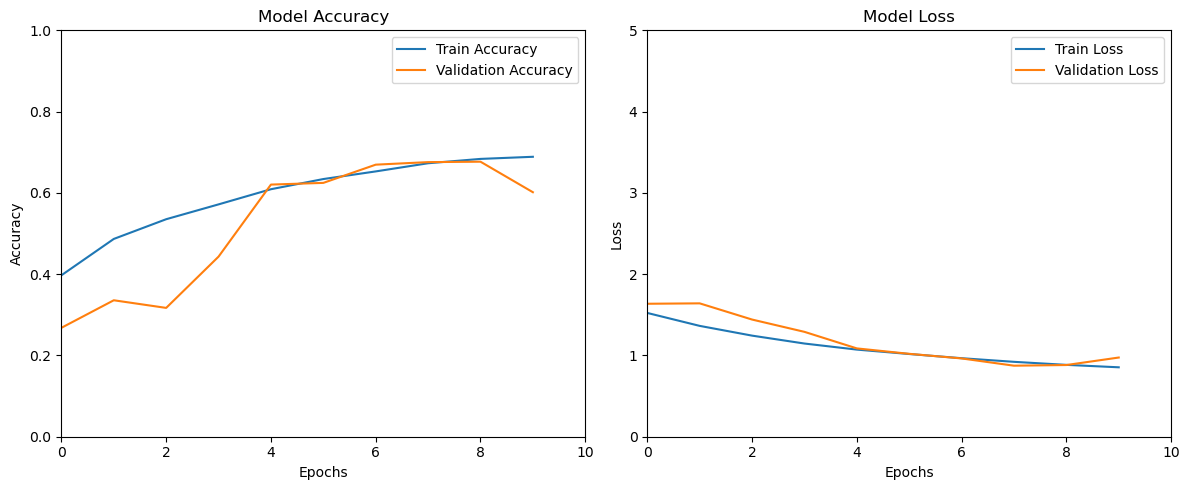

In [53]:
plot_training_history(history)

In [54]:
pd.DataFrame(history.history)

,accuracy,loss,val_accuracy,val_loss
0,0.397235,1.522880,0.267987,1.635946
1,0.486698,1.363786,0.335766,1.640923
2,0.535211,1.243841,0.316997,1.441750
3,0.571727,1.146562,0.443170,1.290362
4,0.609025,1.071902,0.620438,1.086660
5,0.634064,1.017637,0.624609,1.019968
6,0.652843,0.966131,0.669447,0.963199
7,0.672926,0.921446,0.675704,0.873927
8,0.683620,0.884112,0.676747,0.882064
9,0.688837,0.854123,0.601668,0.974354


30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step


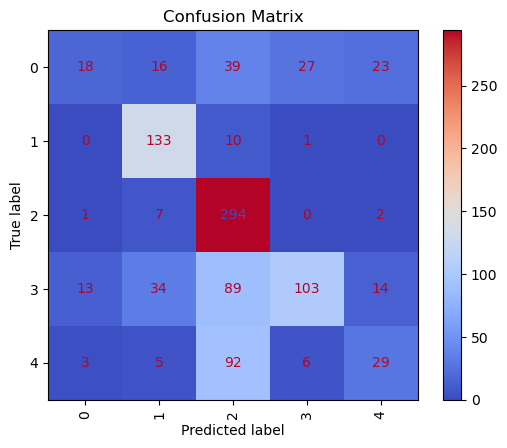

In [55]:
y_pred = model_six.predict(X_test_unbalanced)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test_unbalanced, y_pred_classes)
cm_d = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test_unbalanced))

cm_d.plot(cmap='coolwarm', xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()

In [56]:
from tensorflow.keras.utils import to_categorical

y_train_one_hot = to_categorical(y_train_unbalanced, num_classes=5)
y_test_one_hot = to_categorical(y_test_unbalanced, num_classes=5)

In [57]:
model_seven = create_model_with_dropout(dropout_rate=0.2)

optimiser = Adam(learning_rate=0.0001)
model_seven.compile(
    optimizer=optimiser, 
    loss="categorical_focal_crossentropy", 
    metrics=["accuracy"],  
)

history_focal_loss = model_seven.fit(
    X_train_unbalanced, y_train_one_hot,
    validation_data=(X_test_unbalanced, y_test_one_hot),
    epochs=10,
    batch_size=32,
    class_weight=weights_dict_unbalanced
)

model_seven.save('models/model_seven_focal_loss.keras')

Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 83s 637ms/step - accuracy: 0.2739 - loss: 0.2530 - val_accuracy: 0.2649 - val_loss: 0.2789
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 72s 592ms/step - accuracy: 0.4704 - loss: 0.2004 - val_accuracy: 0.3274 - val_loss: 0.3229
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 66s 553ms/step - accuracy: 0.4767 - loss: 0.1838 - val_accuracy: 0.3306 - val_loss: 0.2856
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 69s 577ms/step - accuracy: 0.5040 - loss: 0.1688 - val_accuracy: 0.4421 - val_loss: 0.1929
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 68s 563ms/step - accuracy: 0.5322 - loss: 0.1515 - val_accuracy: 0.5683 - val_loss: 0.1527
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 67s 561ms/step - accuracy: 0.6076 - loss: 0.1335 - val_accuracy: 0.5203 - val_loss: 0.1532
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 70s 580ms/step - accuracy: 0.6175 - loss: 0.1266 - val_accuracy: 0.5829 - val_loss: 0.1396
Epoch 8/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 68s 565ms/step - accuracy: 0.6524 - loss: 0

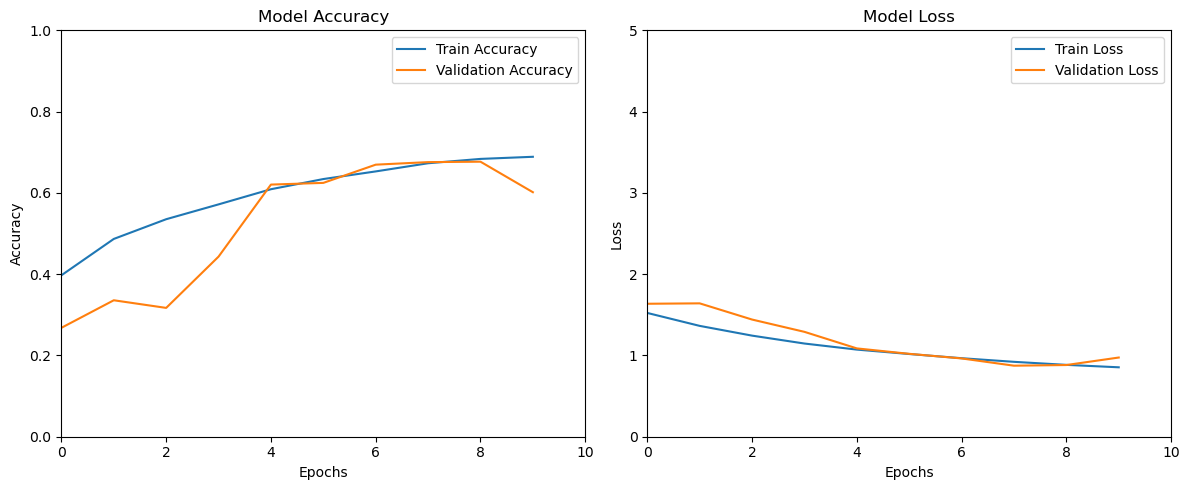

In [58]:
plot_training_history(history)